# XceptionBiFPN: Detección de Deepfakes con Feature Pyramid Network Bidireccional

In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', 'timm', 'albumentations',
    'matplotlib', 'seaborn', 'pandas', 'scikit-learn',
    'opencv-python', 'tqdm'])

0

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler
from PIL import Image

from src.config import make_config, set_seed, MODEL_COLORS
from src.data import build_frame_dataframe, get_transforms, make_loaders
from src.models import XceptionBiFPN, BiFPNLayer, build_model, load_model
from src.engine import train_model, evaluate_by_method
from src.viz import plot_history
from src.config import get_palette

torch.backends.cudnn.benchmark = True

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
CONFIG = make_config(
    DATA_DIR = Path('/home/mariasarachaga/TPF-VA/dataset_split'),
    OUTPUT_DIR    = Path('/home/mariasarachaga/outputs/xception_bifpn'),
    BIFPN_CHANNELS = 256,
    BIFPN_LAYERS   = 2,
)
set_seed(CONFIG['SEED'])

print('Configuración lista:')
for k, v in CONFIG.items():
    print(f'  {k:15s}: {v}')
if CONFIG['DEVICE'] == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Configuración lista:
  DATA_DIR       : /home/mariasarachaga/TPF-VA/dataset_split
  OUTPUT_DIR     : /home/mariasarachaga/outputs/xception_bifpn
  SEED           : 42
  IMG_SIZE       : 299
  BATCH_SIZE     : 32
  LR             : 0.0001
  LR_HEAD        : 0.001
  WEIGHT_DECAY   : 0.0001
  EPOCHS         : 15
  PATIENCE       : 5
  DROPOUT        : 0.3
  NUM_WORKERS    : 4
  DEVICE         : cuda
  BIFPN_CHANNELS : 256
  BIFPN_LAYERS   : 2
GPU: NVIDIA L4


## Implementación BiFPN

In [4]:
_p2 = torch.randn(2, 128, 37, 37)
_p3 = torch.randn(2, 128, 19, 19)
_p4 = torch.randn(2, 128, 10, 10)
_layer = BiFPNLayer(128)
_o2, _o3, _o4 = _layer(_p2, _p3, _p4)
print(f'BiFPNLayer: P2 {_p2.shape}->{_o2.shape}  P3 {_p3.shape}->{_o3.shape}  P4 {_p4.shape}->{_o4.shape}  ✓')
del _p2, _p3, _p4, _layer, _o2, _o3, _o4

BiFPNLayer: P2 torch.Size([2, 128, 37, 37])->torch.Size([2, 128, 37, 37])  P3 torch.Size([2, 128, 19, 19])->torch.Size([2, 128, 19, 19])  P4 torch.Size([2, 128, 10, 10])->torch.Size([2, 128, 10, 10])  ✓


In [5]:
model = XceptionBiFPN(
    dropout        = CONFIG['DROPOUT'],
    bifpn_channels = CONFIG['BIFPN_CHANNELS'],
    num_layers     = CONFIG['BIFPN_LAYERS'],
).to(CONFIG['DEVICE'])

total_p = sum(p.numel() for p in model.parameters())
back_p  = sum(p.numel() for p in model.backbone.parameters())
bifpn_p = (sum(p.numel() for p in model.bifpn.parameters()) +
           sum(p.numel() for p in model.proj.parameters()))
clf_p   = sum(p.numel() for p in model.classifier.parameters())

print(f'Parámetros totales      : {total_p:>12,}')
print(f'  Backbone Xception  : {back_p:>12,}')
print(f'  BiFPN + proyección : {bifpn_p:>12,}')
print(f'  Clasificador       : {clf_p:>12,}')

_dummy = torch.zeros(2, 3, 299, 299).to(CONFIG['DEVICE'])
_out   = model(_dummy)
print(f'\nOutput shape (batch=2)  : {_out.shape}')
del _dummy, _out

/home/mariasarachaga/.local/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Parámetros totales      :   22,263,614
  Backbone Xception  :   20,806,952
  BiFPN + proyección :    1,324,562
  Clasificador       :      132,097

Output shape (batch=2)  : torch.Size([2, 1])


In [6]:
print(CONFIG['DATA_DIR'])
# Luego comprueba si existen archivos ahí con este comando:
import os
print(os.listdir(CONFIG['DATA_DIR']))

/home/mariasarachaga/TPF-VA/dataset_split
['val', 'train', 'test']


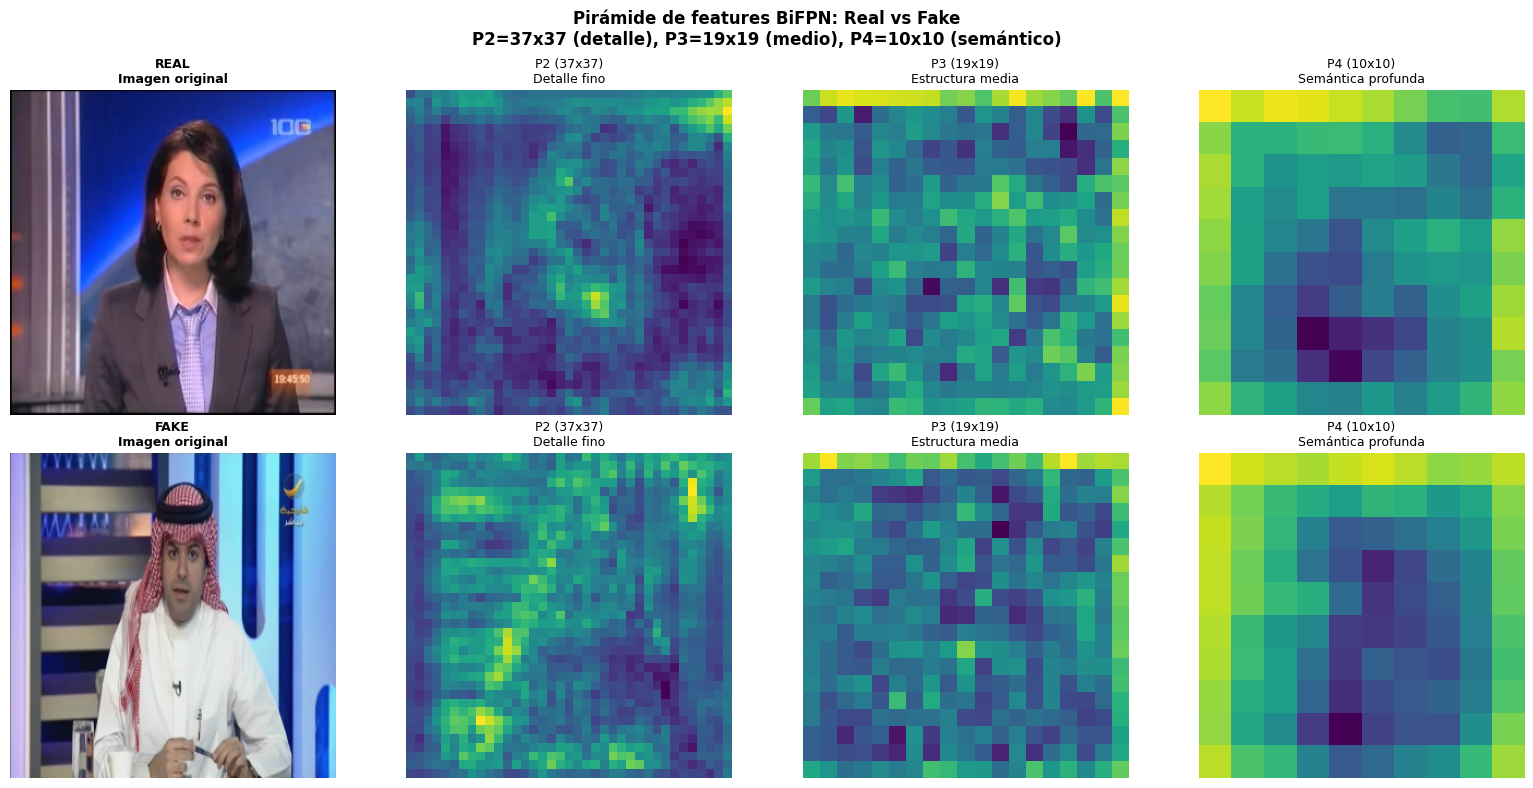

Figura guardada.


In [7]:
df = build_frame_dataframe(CONFIG['DATA_DIR'])
_, val_transforms = get_transforms(CONFIG['IMG_SIZE'])

def visualize_feature_pyramid(model, df, config):
    """
    Visualiza el mapa de activación promedio en cada nivel de la pirámide
    (P2, P3, P4) para una imagen real y una fake, mostrando qué escala
    captura qué tipo de información.
    """
    real_path = df[(df['label'] == 0) & (df['split'] == 'test')].sample(
        1, random_state=1)['path'].values[0]
    fake_path = df[(df['label'] == 1) & (df['split'] == 'test')].sample(
        1, random_state=1)['path'].values[0]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Pirámide de features BiFPN: Real vs Fake\n'
                 'P2=37x37 (detalle), P3=19x19 (medio), P4=10x10 (semántico)',
                 fontsize=12, fontweight='bold')

    model.eval()
    level_names = ['Imagen original', 'P2 (37x37)\nDetalle fino',
                   'P3 (19x19)\nEstructura media', 'P4 (10x10)\nSemántica profunda']

    for row_idx, (path, tag, color) in enumerate([
        (real_path, 'REAL', "#000000"),
        (fake_path, 'FAKE', "#000000"),
    ]):
        img = np.array(Image.open(path).convert('RGB').resize(
            (config['IMG_SIZE'], config['IMG_SIZE'])
        ))
        tensor = val_transforms(image=img)['image'].unsqueeze(0).to(config['DEVICE'])

        with torch.no_grad():
            p2_raw, p3_raw, p4_raw = model.backbone(tensor)
            p2f = model.proj[0](p2_raw)
            p3f = model.proj[1](p3_raw)
            p4f = model.proj[2](p4_raw)
            for layer in model.bifpn:
                p2f, p3f, p4f = layer(p2f, p3f, p4f)

        axes[row_idx, 0].imshow(img)
        axes[row_idx, 0].set_title(f'{tag}\n{level_names[0]}',
                                    color=color, fontweight='bold', fontsize=9)
        axes[row_idx, 0].axis('off')

        for col_idx, (feat, name) in enumerate(zip([p2f, p3f, p4f], level_names[1:])):
            act = feat.squeeze(0).mean(0).cpu().numpy()
            act = (act - act.min()) / (act.max() - act.min() + 1e-9)
            axes[row_idx, col_idx+1].imshow(act, cmap='viridis')
            axes[row_idx, col_idx+1].set_title(name, fontsize=9)
            axes[row_idx, col_idx+1].axis('off')

    plt.tight_layout()
    plt.savefig(config['OUTPUT_DIR'] / 'feature_pyramid_visualization.png', dpi=150)
    plt.show()
    print('Figura guardada.')


visualize_feature_pyramid(model, df, CONFIG)

In [8]:
train_loader, val_loader, test_loader = make_loaders(df, CONFIG)

Train: 43,200 | Val: 8,400 | Test: 8,401


In [9]:
backbone_params = list(model.backbone.parameters())
head_params = (list(model.proj.parameters()) +
               list(model.bifpn.parameters()) +
               [model.level_weights] +
               list(model.classifier.parameters()))

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': CONFIG['LR']},
    {'params': head_params,     'lr': CONFIG['LR_HEAD']},
], weight_decay=CONFIG['WEIGHT_DECAY'])

criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['EPOCHS'], eta_min=1e-6
)
scaler = GradScaler('cuda') if CONFIG['DEVICE'] == 'cuda' else None

print('Optimizer listo.')
print(f'  LR backbone : {optimizer.param_groups[0]["lr"]}')
print(f'  LR BiFPN    : {optimizer.param_groups[1]["lr"]}')

Optimizer listo.
  LR backbone : 0.0001
  LR BiFPN    : 0.001


In [10]:
print('Entrenando XceptionBiFPN\n')
history = train_model(
    model, 'xception_bifpn', train_loader, val_loader,
    optimizer, criterion, scheduler, CONFIG, scaler=scaler
)

Entrenando XceptionBiFPN



Epoch 01/15 | train_loss=0.6237 train_acc=0.6208 | val_loss=0.7033 val_acc=0.6413 val_auc=0.7555  ✓ checkpoint guardado (AUC=0.7555)


Epoch 02/15 | train_loss=0.4787 train_acc=0.7476 | val_loss=0.4690 val_acc=0.7800 val_auc=0.8035  ✓ checkpoint guardado (AUC=0.8035)


Epoch 03/15 | train_loss=0.3868 train_acc=0.8012 | val_loss=0.4902 val_acc=0.8270 val_auc=0.8091  ✓ checkpoint guardado (AUC=0.8091)


Epoch 04/15 | train_loss=0.3260 train_acc=0.8391 | val_loss=0.6672 val_acc=0.7636 val_auc=0.8059  (sin mejora 1/5)


...

Epoch 06/15 | train_loss=0.2529 train_acc=0.8747 | val_loss=0.6916 val_acc=0.8265 val_auc=0.8171  (sin mejora 1/5)


Epoch 07/15 | train_loss=0.2346 train_acc=0.8803 | val_loss=0.7015 val_acc=0.8105 val_auc=0.8132  (sin mejora 2/5)


Epoch 08/15 | train_loss=0.2074 train_acc=0.8949 | val_loss=0.7909 val_acc=0.8317 val_auc=0.8131  (sin mejora 3/5)


Epoch 09/15 | train_loss=0.1894 train_acc=0.9005 | val_loss=0.9470 val_acc=0.8232 val_auc=0.8088  (sin mejora 4/5)


Epoch 10/15 | train_loss=0.1785 train_acc=0.9075 | val_loss=0.9155 val_acc=0.8415 val_auc=0.8123  (sin mejora 5/5)

Early stopping en época 10.


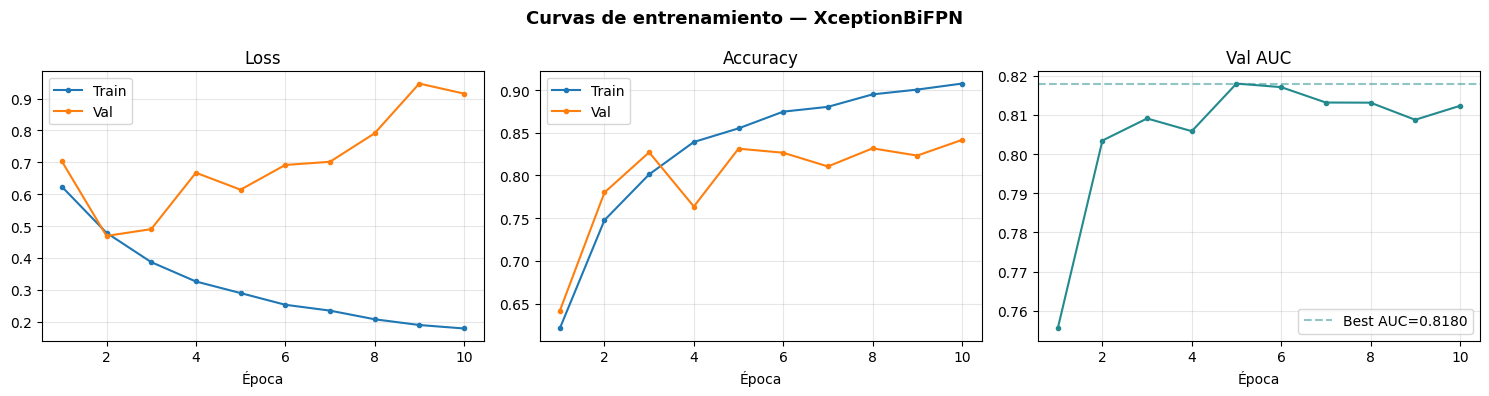

In [11]:
plot_history(history, 'XceptionBiFPN', CONFIG['OUTPUT_DIR'])

In [12]:
model, best_val_auc, best_epoch = load_model(
    model, CONFIG['OUTPUT_DIR'] / 'best_xception_bifpn.pth', CONFIG['DEVICE']
)
print(f"Checkpoint — época {best_epoch} — val AUC: {best_val_auc:.4f}")

print('\nEvaluando en test...\n')
results_df = evaluate_by_method(model, df, CONFIG)
results_df.to_csv(CONFIG['OUTPUT_DIR'] / 'test_results_by_method.csv', index=False)
print(f'\nAUC promedio: {results_df["AUC"].mean():.4f}')

Checkpoint — época 5 — val AUC: 0.8180

Evaluando en test...



  Deepfakes             AUC=0.8791  Acc=0.7471  F1=0.7870


  Face2Face             AUC=0.8141  Acc=0.7132  F1=0.7513


  FaceShifter           AUC=0.8728  Acc=0.7571  F1=0.7971


  FaceSwap              AUC=0.8168  Acc=0.7180  F1=0.7565


  NeuralTextures        AUC=0.7581  Acc=0.6839  F1=0.7188

AUC promedio: 0.8282


/home/mariasarachaga/.local/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


xception — parámetros entrenables: 20,809,001


  Deepfakes             AUC=0.8769  Acc=0.7332  F1=0.7791


  Face2Face             AUC=0.7981  Acc=0.6946  F1=0.7388


  FaceShifter           AUC=0.8608  Acc=0.7329  F1=0.7787


  FaceSwap              AUC=0.8387  Acc=0.7105  F1=0.7556


  NeuralTextures        AUC=0.7438  Acc=0.6654  F1=0.7064

=== Comparación: XceptionBiFPN vs Xception baseline ===

        method  AUC_bifpn  AUC_baseline   Delta
     Deepfakes     0.8791        0.8769  0.0022
     Face2Face     0.8141        0.7981  0.0159
   FaceShifter     0.8728        0.8608  0.0120
      FaceSwap     0.8168        0.8387 -0.0218
NeuralTextures     0.7581        0.7438  0.0142

Δ AUC promedio: +0.0045


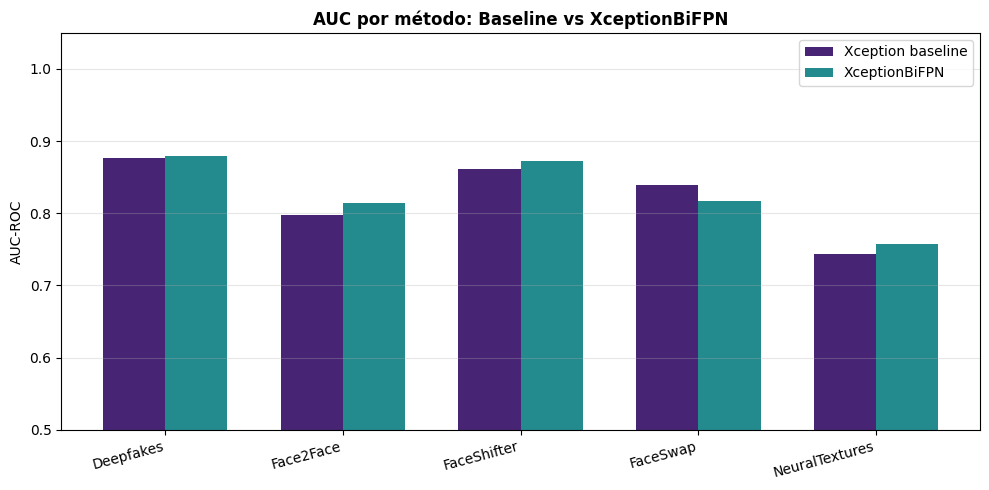

In [13]:
CONFIG['BASELINE_CKPT'] = Path('/home/mariasarachaga/TPF-VA/outputs/best_xception.pth')

if CONFIG['BASELINE_CKPT'].exists():
    baseline = build_model('xception', CONFIG['DEVICE'])
    baseline, _, _ = load_model(baseline, CONFIG['BASELINE_CKPT'], CONFIG['DEVICE'])

    base_df = evaluate_by_method(baseline, df, CONFIG)[['method', 'AUC']] \
                    .rename(columns={'AUC': 'AUC_baseline'})
    comparison = results_df[['method', 'AUC']].rename(columns={'AUC': 'AUC_bifpn'}) \
                           .merge(base_df, on='method')
    comparison['Delta'] = comparison['AUC_bifpn'] - comparison['AUC_baseline']

    print('\n=== Comparación: XceptionBiFPN vs Xception baseline ===\n')
    print(comparison.to_string(index=False, float_format='{:.4f}'.format))
    print(f'\nΔ AUC promedio: {comparison["Delta"].mean():+.4f}')

    fig, ax = plt.subplots(figsize=(10, 5))
    x, w = np.arange(len(comparison)), 0.35
    ax.bar(x - w/2, comparison['AUC_baseline'], w, label='Xception baseline', color=MODEL_COLORS['Baseline'])
    ax.bar(x + w/2, comparison['AUC_bifpn'],    w, label='XceptionBiFPN',     color=MODEL_COLORS['BiFPN'])
    ax.set_xticks(x); ax.set_xticklabels(comparison['method'], rotation=15, ha='right')
    ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC-ROC')
    ax.set_title('AUC por método: Baseline vs XceptionBiFPN', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(CONFIG['OUTPUT_DIR'] / 'auc_comparison.png', dpi=150)
    plt.show()
    comparison.to_csv(CONFIG['OUTPUT_DIR'] / 'auc_comparison.csv', index=False)
else:
    print(f'[!] Baseline no encontrado en {CONFIG["BASELINE_CKPT"]}')

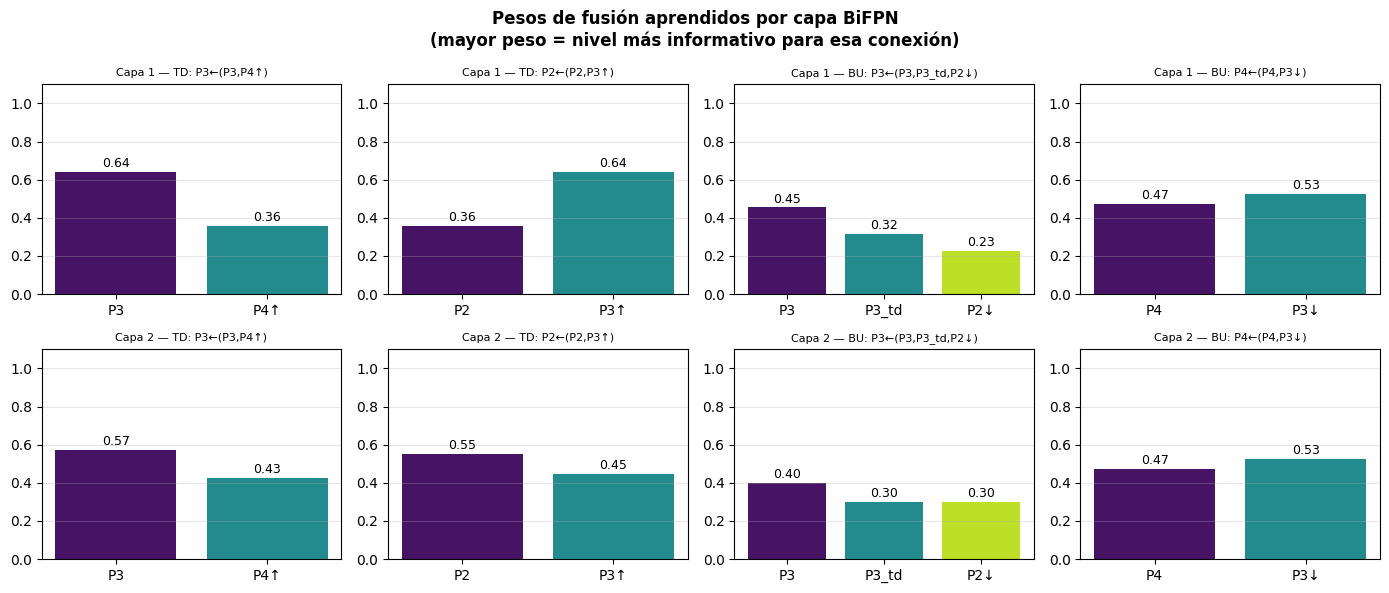

In [14]:
bar_colors = get_palette(3)

def visualize_bifpn_weights(model, config):
    """
    Muestra los pesos de fusión aprendidos por cada capa BiFPN.
    Revela qué nivel de la pirámide contribuye más en cada dirección.
    """
    fig, axes = plt.subplots(config['BIFPN_LAYERS'], 4,
                              figsize=(14, config['BIFPN_LAYERS'] * 3))
    fig.suptitle('Pesos de fusión aprendidos por capa BiFPN\n'
                 '(mayor peso = nivel más informativo para esa conexión)',
                 fontsize=12, fontweight='bold')

    connection_names = ['TD: P3←(P3,P4↑)', 'TD: P2←(P2,P3↑)',
                        'BU: P3←(P3,P3_td,P2↓)', 'BU: P4←(P4,P3↓)']

    for i, layer in enumerate(model.bifpn):
        weight_groups = [
            (layer.w_td_p3, ['P3', 'P4↑']),
            (layer.w_td_p2, ['P2', 'P3↑']),
            (layer.w_bu_p3, ['P3', 'P3_td', 'P2↓']),
            (layer.w_bu_p4, ['P4', 'P3↓']),
        ]
        for j, (w, labels) in enumerate(weight_groups):
            ax = axes[i, j] if config['BIFPN_LAYERS'] > 1 else axes[j]
            w_norm = F.relu(w.detach()).cpu()
            w_norm = (w_norm / (w_norm.sum() + 1e-4)).numpy()
            bars = ax.bar(labels, w_norm, color=bar_colors[:len(labels)])
            for bar, val in zip(bars, w_norm):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9)
            ax.set_title(f'Capa {i+1} — {connection_names[j]}', fontsize=8)
            ax.set_ylim(0, 1.1)
            ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(config['OUTPUT_DIR'] / 'bifpn_fusion_weights.png', dpi=150)
    plt.show()

visualize_bifpn_weights(model, CONFIG)

In [15]:
print('Resumen XceptionBiFPN\n')
best_ep  = history.loc[history['val_auc'].idxmax(), 'epoch']
best_auc = history['val_auc'].max()
print(f'Mejor val AUC  : {best_auc:.4f} (época {int(best_ep)})')
print(f'BiFPN channels : {CONFIG["BIFPN_CHANNELS"]}')
print(f'BiFPN layers   : {CONFIG["BIFPN_LAYERS"]}')
print(f'\nAUC test por método:')
for _, row in results_df.iterrows():
    bar = '█' * int(row['AUC'] * 20)
    print(f'  {row["method"]:20s} {row["AUC"]:.4f}  {bar}')
print(f'\nAUC promedio   : {results_df["AUC"].mean():.4f}')
print(f'Artefactos en  : {CONFIG["OUTPUT_DIR"]}')

Resumen XceptionBiFPN

Mejor val AUC  : 0.8180 (época 5)
BiFPN channels : 256
BiFPN layers   : 2

AUC test por método:
  Deepfakes            0.8791  █████████████████
  Face2Face            0.8141  ████████████████
  FaceShifter          0.8728  █████████████████
  FaceSwap             0.8168  ████████████████
  NeuralTextures       0.7581  ███████████████

AUC promedio   : 0.8282
Artefactos en  : /home/mariasarachaga/outputs/xception_bifpn
